In [1]:
import numpy as np
import os
import importlib
import uxarray as ux
import matplotlib.pyplot as plt
from plotting_functions import SubsetLatLon, Hybrid2plev, ListedCMAP_Wrapper, interp_all_columns, StaticPlotHelper

In [2]:
# Grid
grid_path_SCRIP = '/glade/u/home/nforcone/MidwestVarRes/midwest-06-16-2025_edit22_np4_SCRIP.nc'

# microp_true
run_dir_microp_true = '/glade/work/nforcone/August2020data/run_data/ZM_on_microp_uniform'

true34560 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-34560.nc'
true46080 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-46080.nc'
true57600 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-57600.nc'
true69120 = 'StormSPEED.stormspeed_refmesh_FHISTC_LTso_ne0MIDWESTne30x32_ne0MIDWESTne30x32_20200810_land_ZM_on_microp_uniform.cam.h0i.2020-08-10-69120.nc'
true_paths = [os.path.join(run_dir_microp_true, true34560),
              os.path.join(run_dir_microp_true, true46080),
              os.path.join(run_dir_microp_true, true57600),
              os.path.join(run_dir_microp_true, true69120)]

uxds_microp_true = ux.open_mfdataset(grid_path_SCRIP, true_paths)

In [3]:
my_xlims = (-95, -85)
my_ylims = (39, 45)

U500 = SubsetLatLon(uxds_microp_true, "U500", my_xlims, my_ylims)
V500 = SubsetLatLon(uxds_microp_true, "V500", my_xlims, my_ylims)
Z500 = Hybrid2plev(uxds_microp_true, "Z3", my_xlims, my_ylims,
                   np.asarray([50000.]),
                   "log",
                   True)
Z200 = Hybrid2plev(uxds_microp_true, "Z3", my_xlims, my_ylims,
                   np.asarray([20000.]),
                   "log",
                   True)
PRECT = SubsetLatLon(uxds_microp_true, "PRECT", my_xlims, my_ylims)

In [4]:
PRECT[0].max().values

array(5.1702616e-05, dtype=float32)

In [5]:
PRECT_bounds = np.linspace(0, 5.0e-5, 21)
PRECT_bounds

array([0.00e+00, 2.50e-06, 5.00e-06, 7.50e-06, 1.00e-05, 1.25e-05,
       1.50e-05, 1.75e-05, 2.00e-05, 2.25e-05, 2.50e-05, 2.75e-05,
       3.00e-05, 3.25e-05, 3.50e-05, 3.75e-05, 4.00e-05, 4.25e-05,
       4.50e-05, 4.75e-05, 5.00e-05])

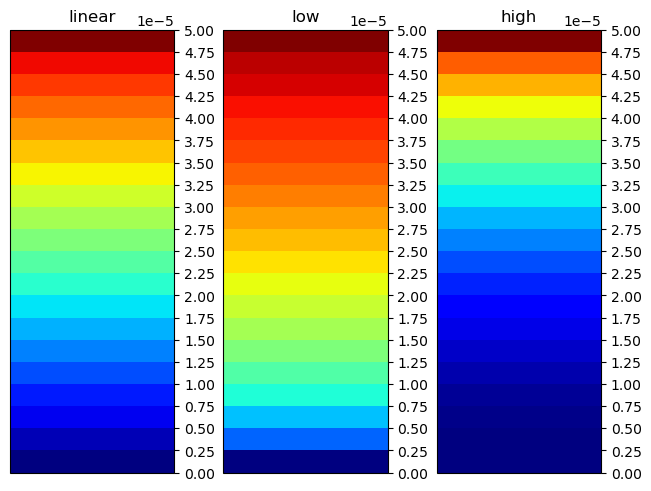

In [6]:
PRECT_color_norm, PRECT_lin_cm, PRECT_low_cm, _ = ListedCMAP_Wrapper(PRECT_bounds, 'jet')

In [7]:
Z500_bounds = np.arange(5760, 5912, 10)
Z500_bounds

array([5760, 5770, 5780, 5790, 5800, 5810, 5820, 5830, 5840, 5850, 5860,
       5870, 5880, 5890, 5900, 5910])

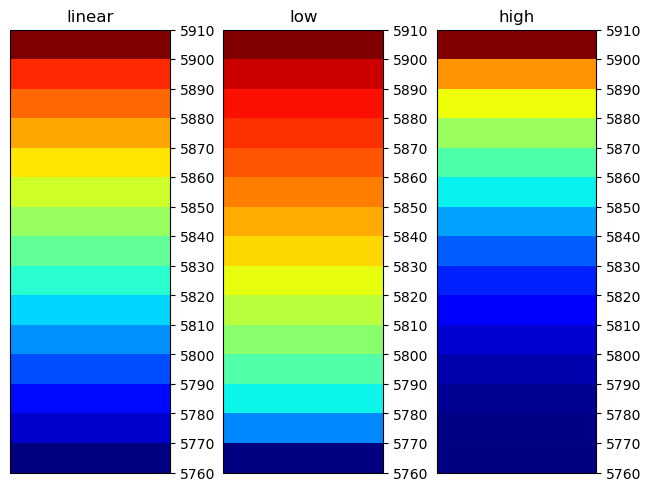

In [8]:
Z500_color_norm, Z500_lin_cm, _, _ = ListedCMAP_Wrapper(Z500_bounds, 'jet')

In [9]:
destination_zlevs_meters = np.array([400, 500, 600, 700])
destination_zlevs_meters

array([400, 500, 600, 700])

In [10]:
interped_ux = interp_all_columns(uxds_microp_true, "OMEGA", my_xlims, my_ylims, destination_zlevs_meters)
interped_ux

flipping dimension  lev


<xarray.UxDataArray (time: 48, lev: 4, n_face: 45247)> Size: 69MB
dask.array<transpose, shape=(48, 4, 45247), dtype=float64, chunksize=(12, 4, 45247), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 384B 2020-08-10 09:36:00 ... 2020-08-10 22:08:00
  * lev      (lev) int64 32B 400 500 600 700
Dimensions without coordinates: n_face

In [11]:
interped_ux.compute()[0, :, 200]

<xarray.UxDataArray (lev: 4, n_face: 1)> Size: 32B
array([[-0.22709872],
       [-0.38624127],
       [-0.52524161],
       [-0.62253366]])
Coordinates:
    time     object 8B 2020-08-10 09:36:00
  * lev      (lev) int64 32B 400 500 600 700
Dimensions without coordinates: n_face

### Manual one column interpolation check
https://docs.xarray.dev/en/stable/examples/apply_ufunc_vectorize_1d.html

In [12]:
OMEGA_subset = SubsetLatLon(uxds_microp_true, "OMEGA", my_xlims, my_ylims)
Z3_subset = SubsetLatLon(uxds_microp_true, "Z3", my_xlims, my_ylims)

In [13]:
Z3_bottom_to_top = np.flip(Z3_subset, axis=1)
some_Z3 = Z3_bottom_to_top[0, 0:6, 200].values.squeeze()
some_Z3

array([346.13757, 402.10748, 473.60934, 551.9017 , 637.6851 , 731.6924 ],
      dtype=float32)

In [14]:
OMEGA_bottom_to_top = np.flip(OMEGA_subset, axis=1)
some_OMEGA = OMEGA_bottom_to_top[0, 0:6, 200].values.squeeze()
some_OMEGA

array([-0.30804512, -0.22393152, -0.34606844, -0.4652479 , -0.5722468 ,
       -0.6481088 ], dtype=float32)

In [15]:
OMEGA_interped_to_zlevs = np.interp(destination_zlevs_meters, some_Z3, some_OMEGA)
OMEGA_interped_to_zlevs

array([-0.22709872, -0.38624127, -0.52524161, -0.62253366])

### Plot Cross Section

In [16]:
start_point = (-95, 42.5)  # (lon, lat)
end_point = (-85, 42.5)
time_ind = 0

cross_section_gca = interped_ux[time_ind].cross_section(start=start_point, end=end_point, steps=150)

In [17]:
def set_lon_lat_xticks(ax, cross_section, n_ticks=6):
    """Utility function to draw stacked lat/lon points along the sampled cross-section"""
    da = cross_section

    N = da.sizes["steps"]
    tick_pos = np.linspace(0, N - 1, n_ticks, dtype=int)
    lons = da["lon"].values[tick_pos]
    lats = da["lat"].values[tick_pos]

    tick_labels = []
    for lon, lat in zip(lons, lats):
        lon_dir = "E" if lon >= 0 else "W"
        lat_dir = "N" if lat >= 0 else "S"
        tick_labels.append(f"{abs(lon):.2f}°{lon_dir}\n{abs(lat):.2f}°{lat_dir}")

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel("Longitude\nLatitude")
    plt.tight_layout()

    return fig, ax

Text(0.5, 1.0, 'Cross Section between (-95, 42.5) and (-85, 42.5)')

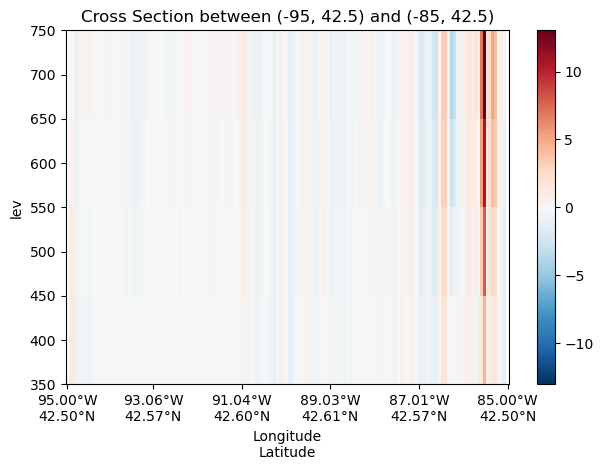

In [18]:
fig, ax = plt.subplots()
cross_section_gca.plot(ax=ax)
set_lon_lat_xticks(ax, cross_section_gca)
ax.set_title(f"Cross Section between {start_point} and {end_point}")

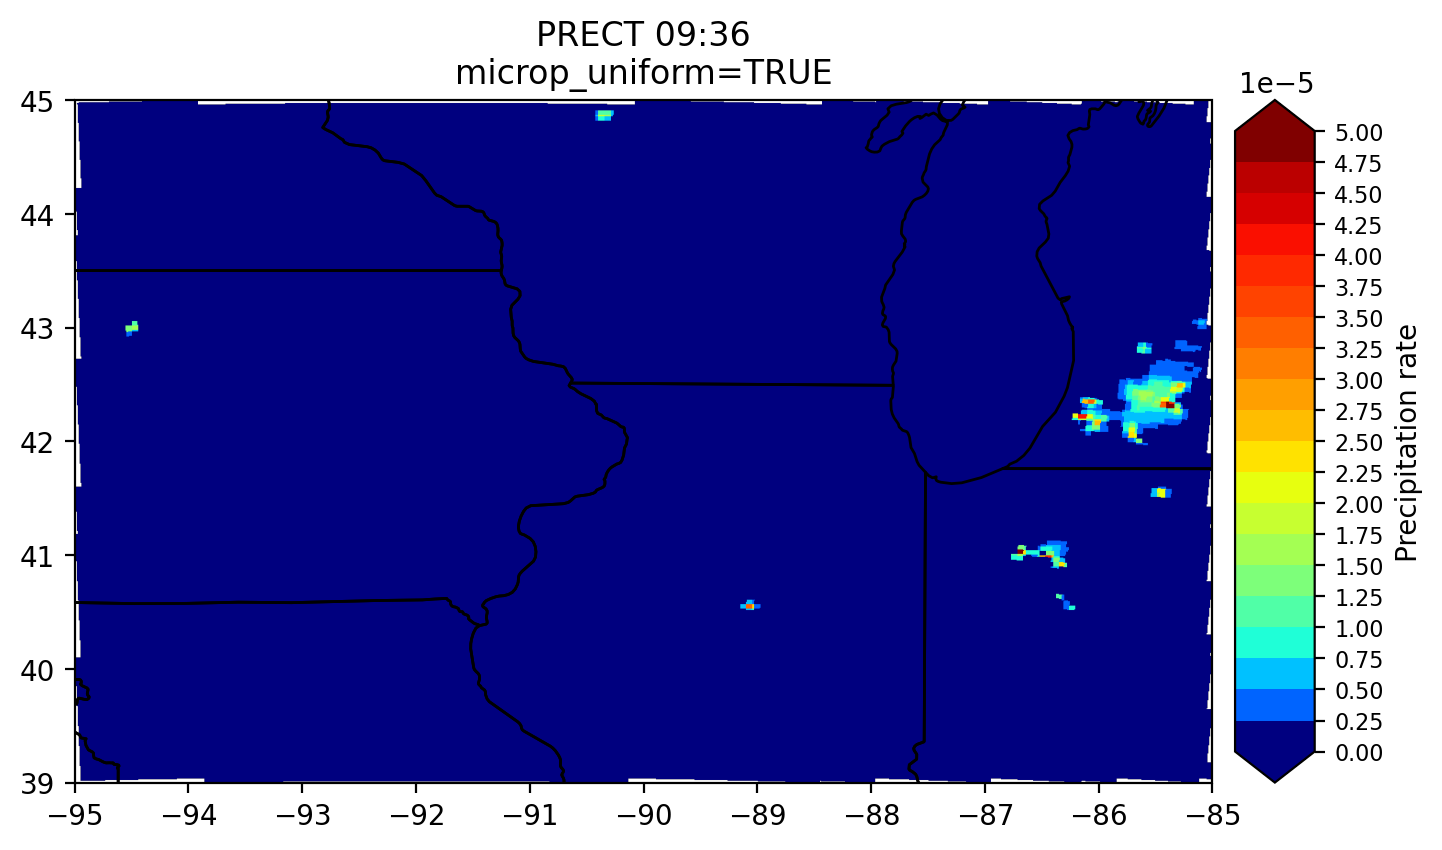

In [19]:
StaticPlotHelper(PRECT,
                 "PRECT",
                 "TRUE",
                 my_xlims,
                 my_ylims,
                 PRECT_low_cm,
                 PRECT_bounds,
                 PRECT_color_norm,
                 "Precipitation rate")